<a href="https://colab.research.google.com/github/romulo-souza/Deep_Learning/blob/main/CNNs/CNNs_Pre_Treinadas/CNN_Resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# As versões originais e pré-treinadas da ResNet (como ResNet-18, ResNet-50, ResNet-101) foram treinadas no dataset ImageNet. Este é um dos maiores bancos de dados para visão computacional, contendo mais de 14 milhões de imagens classificadas em 1.000 categorias diferentes.

Quando usamos uma ResNet “pré-treinada”, ela já vem com pesos configurados a partir desse treinamento inicial, permitindo aplicar transfer learning e adaptar o modelo para novas tarefas com menos dados e menor tempo de treinamento

In [6]:
import keras
from keras import applications, preprocessing
import numpy as np
from matplotlib import pyplot as plt

In [7]:
# Carregar a CNN pré-treinada ResNet com os pesos obtidos a partir do treinamento dessa rede no dataset Imagenet
model = applications.resnet.ResNet50(weights = 'imagenet')

## Pré processamento da imagem de entrada

In [8]:
img_path = 'imagem_laranja.png'
img = preprocessing.image.load_img(img_path, target_size=(224, 224)) # carregamento da imagem e redimensionamento para 224x224px (tamnho esperado pela ResNet)

# Transformar a imagem em um array do numpy
x = preprocessing.image.img_to_array(img)

# Transformar a imagem em um lote de entrada, mesmo que seja apenas uma imagem, o modelo espera um lote
x = np.expand_dims(x, axis=0)

# Pré processamento da imagem de entrada de acordo com o que a ResNet espera
x = applications.resnet.preprocess_input(x)

## Predição do modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predição:
1: orange (96.25%)
2: lemon (3.15%)
3: plate (0.13%)


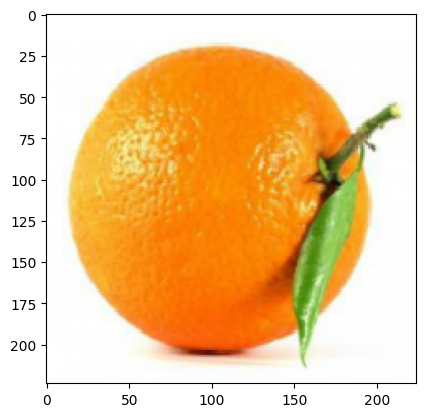

In [9]:
# Retorna um array numpy de predições
preds = model.predict(x)

# Decodificar a predição, mostrando as 3 primeiras classes
decoded_preds = applications.resnet50.decode_predictions(preds, top=3)[0]

# Mostrar imagem
plt.imshow(img)

# Mostrar predição
print('Predição:')

for i, (imagenet_id, label, score) in enumerate(decoded_preds):
  print(f'{i+1}: {label} ({score*100:.2f}%)')
